<hr>

# Projektübersicht: Roadkill-Datenanalyse

In diesem Projekt geht es um Tiere, die gesichtet wurden, nach dem sie dem Verkehr zum Opfer gefallen sind (Roadkill). 

## Datenquellen

* **[Zenodo: Roadkill-Datensatz (Quality Level 2)](https://zenodo.org/records/14748235?preview_file=2024_Roadkill_Q2.csv)**
  Hauptdatensatz dieser Arbeit (2014–2023). Konsistente Datenstruktur, jedoch ohne professionelle Überprüfung der gemeldeten Arten.
* **[GBIF-Datensatz (Quality Level 1)](https://www.gbif.org/dataset/d0d5ef85-71b2-4da6-b6f6-c1c3d60987d3)**
  Dieser Datensatz wurde nicht verwendet aber für Interressierte.
* **[Roadkill.at Ergebnisse](https://roadkill.at/forschung-ergebnisse/daten)**
  Offizielle Plattform und Dashboards des Forschungsprojekts.
* **[Body Mass](https://opentraits.org/datasets/elton-traits.html, Downloaded: https://figshare.com/ndownloader/files/5631084)**
  To Match Animals to Bodymasses so it can be analysed if their sizes influence how likely they are to die.

## Citation for Zenodo: Roadkill-Datensatz

> Heigl, Florian, & Roadkill Community. (2025). *Roadkill Dataset 2014-2023 Quality level 2* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.5878813

## Forschungsfragen

### **Frage 1:** Welches Tier (bzw. welche Tierklasse) ist am anfälligsten dafür, überfahren zu werden?
### **Frage 2:** Gibt es eine Korrelation zwischen der Körpergröße (Masse) eines Tieres und den Todesfällen?
### **Frage 3:** Wo und wann werden die meisten Tiere überfahren, und nehmen die Zahlen über die Jahre hinweg zu?

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import geopandas as gpd
#from shapely.geometry import Point
import statsmodels.api as sm

from scipy import stats
from scipy.stats import spearmanr
from scipy.optimize import curve_fit

#Heat Map
from folium.plugins import HeatMap
import folium
from IPython.display import IFrame

#Graphic Carosell
import ipywidgets as widgets
from IPython.display import display, Image, clear_output

In [173]:
pd.set_option('display.max_columns', None)#See all columns, without truncation
pd.set_option('display.max_colwidth', None)#See full content of each column, without truncation
pd.set_option('display.max_rows', 100)#Set max to 100 

# Load data, separated by ;
df_animals = pd.read_csv("data/2024_Roadkill_Q2.csv", sep=";")


print("\nDATA INFO")
print(df_animals.info())#show entries, columns, non-null counts, and data types
#T is for Transpose (side Info)
df_animals.head()#last line creats an interactive table
# 2. Use pandas' built-in mini-styler to display it beautifully


DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11267 entries, 0 to 11266
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   occurrenceID              11267 non-null  object 
 1   basisOfRecord             11267 non-null  object 
 2   catalogNumber             11267 non-null  int64  
 3   decimalLatitude           11267 non-null  float64
 4   decimalLongitude          11267 non-null  float64
 5   USER_ID                   11267 non-null  int64  
 6   associatedMedia           429 non-null    object 
 7   individualCount           11267 non-null  int64  
 8   eventDate                 11267 non-null  object 
 9   scientificName            11267 non-null  object 
 10  scientificNameAuthorship  11266 non-null  object 
 11  countryCode               11266 non-null  object 
 12  geodaticDatum             11267 non-null  object 
 13  CNTRY_NAME                11267 non-null  object 


,occurrenceID,basisOfRecord,catalogNumber,decimalLatitude,decimalLongitude,USER_ID,associatedMedia,individualCount,eventDate,scientificName,scientificNameAuthorship,countryCode,geodaticDatum,CNTRY_NAME,identifiedBy,rank,kingdom,phylum,class,order,family,genus,species,Unschaerferadius,name,gu_a3,name_en,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,boku:spotteron:roadkill:id:18,HumanObservation,18,47.709599,16.141620,651,NaN,1,06.02.14,"Lepus europaeus Pallas, 1778","Pallas, 1778",AUT,WGS84,Austria,NaN,SPECIES,Animalia,Chordata,Mammalia,Lagomorpha,Leporidae,Lepus,europaeus,500m,Niederösterreich,AUT,Lower Austria,NaN,NaN,NaN,NaN,NaN
1,boku:spotteron:roadkill:id:21,HumanObservation,21,48.240592,16.345595,590,NaN,1,27.02.14,"Mustelidae Fischer von Waldheim, 1817","Fischer von Waldheim, 1817",AUT,WGS84,Austria,NaN,FAMILY,Animalia,Chordata,Mammalia,Carnivora,Mustelidae,NaN,NaN,500m,Wien,AUT,Vienna,NaN,NaN,NaN,NaN,NaN
2,boku:spotteron:roadkill:id:23,HumanObservation,23,48.067333,16.478023,621,https://files.spotteron.com/images/spots/000002/2014/02/532609f44a-roadkill-2014-02-27-2028.jpg,1,27.02.14,"Lepus europaeus Pallas, 1778","Pallas, 1778",AUT,WGS84,Austria,NaN,SPECIES,Animalia,Chordata,Mammalia,Lagomorpha,Leporidae,Lepus,europaeus,500m,Niederösterreich,AUT,Lower Austria,NaN,NaN,NaN,NaN,NaN
3,boku:spotteron:roadkill:id:24,HumanObservation,24,48.078700,16.571629,621,https://files.spotteron.com/images/spots/000002/2014/02/d5c29a5f40-roadkill-2014-03-20-1318.jpg,1,28.02.14,"Mustelidae Fischer von Waldheim, 1817","Fischer von Waldheim, 1817",AUT,WGS84,Austria,NaN,FAMILY,Animalia,Chordata,Mammalia,Carnivora,Mustelidae,NaN,NaN,500m,Niederösterreich,AUT,Lower Austria,NaN,NaN,NaN,NaN,NaN
4,boku:spotteron:roadkill:id:25,HumanObservation,25,46.981970,15.566806,590,NaN,1,01.03.14,"Felis catus Linnaeus, 1758","Linnaeus, 1758",AUT,WGS84,Austria,NaN,SPECIES,Animalia,Chordata,Mammalia,Carnivora,Felidae,Felis,catus,500m,Steiermark,AUT,Styria,NaN,NaN,NaN,NaN,NaN


The data includes, primary key, internal id (can be same as primary key),User_ID, 
basis (circumstance like seeing), if there is Media an link, eventDate (Date,Time), GPS Coordinates (Latitude/Longitude), uncertainty radius of the location, Country_Name/English and Kürzel, Bundesland if, 
Biologische Klassification rank(highest used) (Species->Genus->Famil->Order->Class->Phylum->Kingdom (Tier)), Scientific Name (incl. Author), how many were spotted, identifiedBy

In [197]:
print("\nMISSING VALUES")
print(df_animals.isnull().sum())


MISSING VALUES
occurrenceID                    0
basisOfRecord                   0
catalogNumber                   0
decimalLatitude                 0
decimalLongitude                0
USER_ID                         0
associatedMedia             10838
individualCount                 0
eventDate                    4417
scientificName                  0
scientificNameAuthorship        1
countryCode                     1
geodaticDatum                   0
CNTRY_NAME                      0
identifiedBy                11260
rank                            0
kingdom                         0
phylum                          0
class                           0
order                        1503
family                       1789
genus                        2466
species                      5053
Unschaerferadius               13
name                         2352
gu_a3                        2352
name_en                      2352
Unnamed: 27                 11267
Unnamed: 28                 1126

In [175]:
print("\nDATA DESCRIPTION")
df_animals.describe(include='object')#this gives a summary of the categorical columns, including the count, unique values, top value, and frequency of the top value.
#frequency being the number of the most com value


DATA DESCRIPTION


,occurrenceID,basisOfRecord,associatedMedia,eventDate,scientificName,scientificNameAuthorship,countryCode,geodaticDatum,CNTRY_NAME,identifiedBy,rank,kingdom,phylum,class,order,family,genus,species,Unschaerferadius,name,gu_a3,name_en
count,11267,11267,429,11267,11267,11266,11266,11267,11267,7,11267,11267,11267,11267,9764,9478,8801,6214,11254,8915,8915,8915
unique,11267,1,429,6086,194,65,35,1,35,4,8,1,1,4,28,70,113,123,2,12,1,9
top,boku:spotteron:roadkill:id:18,HumanObservation,https://files.spotteron.com/images/spots/000002/2014/02/532609f44a-roadkill-2014-02-27-2028.jpg,22.12.18,"Erinaceus Linnaeus, 1758","Linnaeus, 1758",AUT,WGS84,Austria,Norbert Teufelbauer (BirdLife Austria),SPECIES,Animalia,Chordata,Mammalia,Erinaceomorpha,Erinaceidae,Erinaceus,europaeus,500m,Niederösterreich,AUT,Lower Austria
freq,1,11267,1,76,2435,7160,8915,11267,8916,4,6120,11267,11267,8752,2437,2437,2435,1908,11251,2654,8915,4758


In [176]:
print("\nUNIQUE SPECIES")
df_animals['species'].unique().tolist()#gives a list of unique species


UNIQUE SPECIES


['europaeus',
 nan,
 'catus',
 'capreolus',
 'vulpes',
 'vulgaris',
 'meles',
 'cricetus',
 'fragilis',
 'citellus',
 'elaphus',
 'collybita',
 'scrofa',
 'rupicapra',
 'viridis',
 'colchicus',
 'arborea',
 'foina',
 'merula',
 'bufo',
 'domesticus',
 'livia domestica',
 'natrix',
 'europaea',
 'salamandra',
 'nivalis',
 'corone',
 'atra',
 'alba',
 'lupus familiaris',
 'coelebs',
 'dalmatina',
 'cuniculus',
 'buteo',
 'perdix',
 'temporaria',
 'lotor',
 'erminea',
 'major',
 'putorius',
 'citrinella',
 'carduelis',
 'aluco',
 'agilis',
 'alpestris',
 'fiber',
 'longissimus',
 'martes',
 'austriaca',
 'mephitis',
 'fuscus',
 'nisus',
 'virginiana',
 'novaeseelandiae',
 'vulpecula',
 'tibicen',
 'ochruros',
 'melanotus',
 'platyrhynchos',
 'palumbus',
 'monedula',
 'cristatus',
 'caeruleus',
 'hudsonicus',
 'argentatus',
 'pilaris',
 'rubecula',
 'lutra',
 'virginianus',
 ' latrans',
 'cinerea',
 'tinnunculus',
 'canadensis',
 'auritus',
 'philomelos',
 'dorsatus',
 'carolinensis',
 'au

Shows Data for all that have been recorded in austria and have an Media(Picture).

In [177]:
df_animals[(df_animals['CNTRY_NAME'] == 'Austria') & (df_animals['associatedMedia'].notna())].head().filter(['name', 'species', 'scientificName','associatedMedia'])

,name,species,scientificName,associatedMedia
2,Niederösterreich,europaeus,"Lepus europaeus Pallas, 1778",https://files.spotteron.com/images/spots/000002/2014/02/532609f44a-roadkill-2014-02-27-2028.jpg
3,Niederösterreich,NaN,"Mustelidae Fischer von Waldheim, 1817",https://files.spotteron.com/images/spots/000002/2014/02/d5c29a5f40-roadkill-2014-03-20-1318.jpg
7,Steiermark,NaN,"Anura Fischer von Waldheim, 1813",https://files.spotteron.com/images/spots/000002/2014/03/b80da1e415-roadkill-2014-03-15-1155.jpg
10,Niederösterreich,europaeus,"Lepus europaeus Pallas, 1778",https://files.spotteron.com/images/spots/000002/2014/03/8053ad97f1-roadkill-2014-03-17-1542.jpg
13,Wien,NaN,"Anura Fischer von Waldheim, 1813",https://files.spotteron.com/images/spots/000002/2014/03/b1f78aaf21-roadkill-2014-03-19-0027.jpg


Image-Carousel: to showcase pcitures

In [178]:
#Prompted with Gemini, to better showcase the associated Media, I wanted to include a Image Carousel
#Because the names (nyctocorax) don't really tell you anything and the focus are the animals for me.
#So let's see pictures of cute animals...I meant roadkills...

# 1. Gather your image URLs (filtering out NaNs)
# Replace this with your actual filtered dataframe URLs
image_urls = df_animals[df_animals['associatedMedia'].notna()]['associatedMedia'].head(30).tolist()

# 2. Create UI Elements
out = widgets.Output()
prev_button = widgets.Button(description="◀ Previous", button_style='info')
next_button = widgets.Button(description="Next ▶", button_style='info')

# Track the current image index
current_index = 0

def display_current_image():
    with out:
        clear_output(wait=True)
        if image_urls:
            print(f"Showing image {current_index + 1} of {len(image_urls)}")
            # Fetch and display the image directly from the URL
            display(Image(url=image_urls[current_index], width=500))
        else:
            print("No images found in the selection!")

# 3. Define Button Click Actions
def on_next_clicked(b):
    global current_index
    if current_index < len(image_urls) - 1:
        current_index += 1
        display_current_image()

def on_prev_clicked(b):
    global current_index
    if current_index > 0:
        current_index -= 1
        display_current_image()

next_button.on_click(on_next_clicked)
prev_button.on_click(on_prev_clicked)

# 4. Render Layout
controls = widgets.HBox([prev_button, next_button])
display(controls, out)

# Initialize the first image Number 14 is a beautiful animal
display_current_image()

Output()

Welches Tier ist am Anfälligsten überfahren zu werden?

Most Common Roadkill Categories ---
class
Mammalia    8752
Aves        1888
Amphibia     459
Reptilia     168
Name: count, dtype: int64


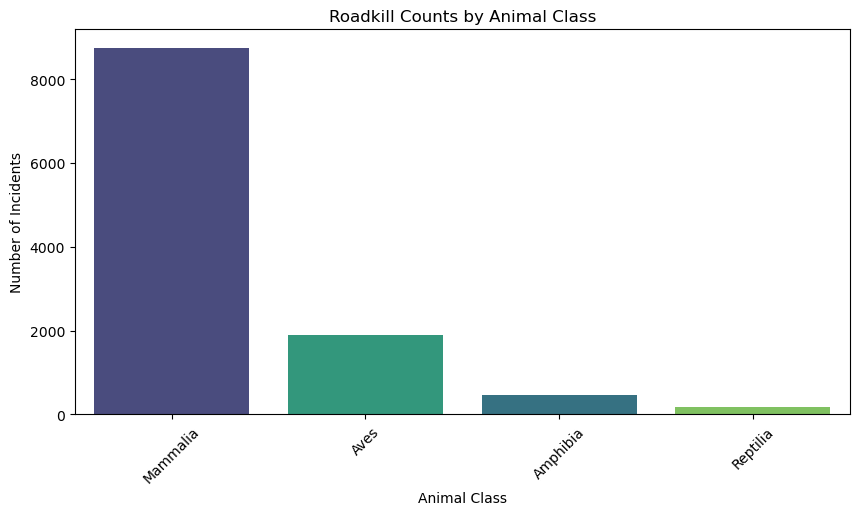

In [179]:
print("Most Common Roadkill Categories ---")
# Using 'name' or 'scientificName'. 'name' usually holds the common name if available.
top_kills = df_animals['class'].value_counts()
print(top_kills)

# Let's plot the broad classes (Mammals, Amphibians, Birds, Reptiles)
plt.figure(figsize=(10, 5))#params: width, height in inches
#Seaborn countplot for better aesthetics, has nice color palettes
#hue is used to separate the bars by class, order is used to sort the bars by count, palette is used to set the color scheme
sns.countplot(data=df_animals, x='class', hue='class', order=df_animals['class'].value_counts().index, palette='viridis')
plt.title('Roadkill Counts by Animal Class')
plt.ylabel('Number of Incidents')
plt.xlabel('Animal Class')
plt.xticks(rotation=45)#Just for style
plt.show()

In [180]:
least_killed_class = top_kills.index[-1] 

#Filter df_animals for that specific class, Mammals
least_killed = df_animals[df_animals['class'] == least_killed_class]

name =least_killed.tail(1).filter(['scientificName'])#Show also the least affected Animal
print(f"Least Commonly Killed Animal: {name} Count: {least_killed.shape[0]}")

#extract string:
name = name.values[0][0]  # This will give you the string value of the scientific name 
#To get an image, the Media needs to be filled and we are looking for the mysterious animal and then match the column, get first element
image_url = df_animals[(df_animals['associatedMedia'].notna())& (df_animals['scientificName'] == name)]['associatedMedia'].iloc[0]

#Image object that has File location: animal.png and Type: image
display(Image(url=image_url, width=500))

Least Commonly Killed Animal:              scientificName
11085  Squamata Oppel, 1811 Count: 168


Verteilung unter den Säugetieren

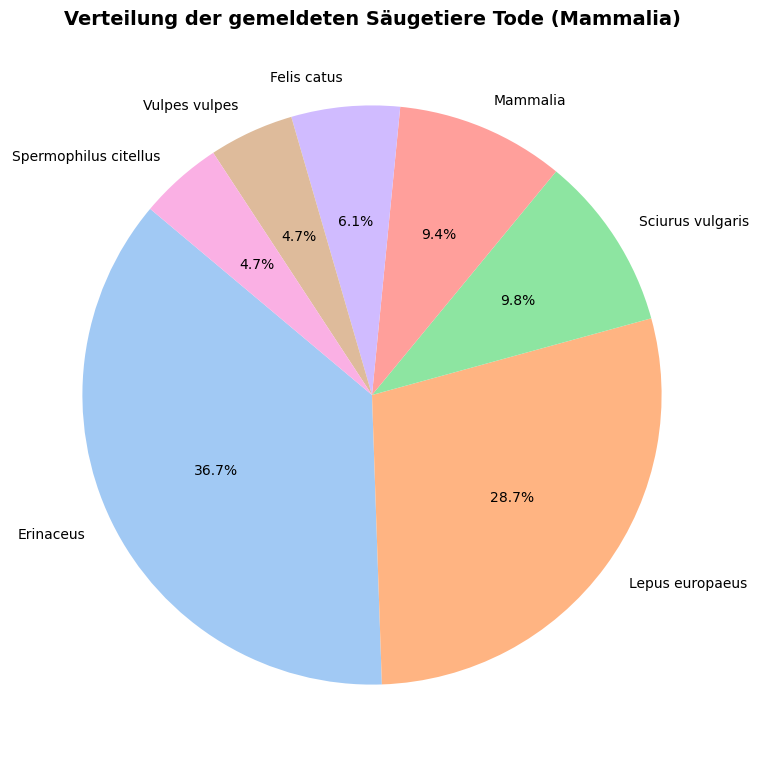

In [181]:
# Filter Mammals
df_mammals = df_animals[df_animals['class'] == 'Mammalia']
#scientificName can be the format "Genus species, subspecies Author, Year
# Split on comma, keep first element
before_comma = df_mammals['scientificName'].str.split(',').str[0].str.strip()

# rsplit(' ', n=1) splits the string only at the VERY LAST space, 
# and .str[0] keeps everything to the left of that split.
cleaned_names = before_comma.str.rsplit(' ', n=1).str[0]

# Now cleaned_names holds the perfect, clean species names for your counts!
mammals = cleaned_names.value_counts()

# Filter species that are less than 3% of total
mammal_counts = mammals[mammals > mammals.sum() * 0.03] 


# Create the Pie Chart
plt.figure(figsize=(8, 8))

#clean color palette, for number of entries
colors = sns.color_palette('pastel')[0:len(mammal_counts)]

plt.pie(
    mammal_counts, 
    labels=mammal_counts.index, 
    autopct='%1.1f%%',# Shows the percentage breakdown inside the slices
    startangle=140,# Rotates the starting to show the bigger pieces below (looks better)
    colors=colors,
)

plt.title('Verteilung der gemeldeten Säugetiere Tode (Mammalia)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [182]:
# Grab the most killed mammal
name = mammal_counts.index[0]# This returns the name like "Lepus europaeus"
count = mammal_counts.iloc[0]# DEATHS

print(f"Most Killed Animal: {name} (Count: {count})")

#extract string:
# Filter the whole table down to matching rows, then grab this specific column from the result dataframe[filter][grab], iloc[0] gets the first row
filtered_series = df_animals[(df_animals['associatedMedia'].notna()) & (df_animals['scientificName'].str.contains(name, na=False))]['associatedMedia'].iloc[0]

display(Image(url=filtered_series, width=500))

Most Killed Animal: Erinaceus (Count: 2435)


Gibt es eine korrelation zwischen Größe und Tod? In English: How does size relate to survival on the road?

In [183]:
# Load traits, data for Body Mass is needed
traits = pd.read_csv("data/MamFuncDat.txt", sep="\t")

#Very Smart to create a new column that combines genus and species into a single key for easier merging with the traits dataset and reading
df_animals["species_key"] = (df_animals["genus"].str.strip() + " " +df_animals["species"].str.strip())

#Map the old column without spaces to the same name, for merging
traits["species_key"] = traits["Scientific"].str.strip()

#genus first word, remove spaces
traits["genus"] = (traits["Scientific"].str.split().str[0].str.strip())

# First match is with Species-level (highest accuracy on right mass)
df_sizes = df_animals.merge(traits[["species_key", "BodyMass-Value"]],on="species_key",how="left")

# Genus median
genus_median = traits.groupby("genus")["BodyMass-Value"].median()

# Family median
family_median = traits.groupby("MSWFamilyLatin")["BodyMass-Value"].median()

# Fill missing values
df_sizes["BodyMass-Value"] = (df_sizes["BodyMass-Value"].fillna(df_sizes["genus"].map(genus_median)).fillna(df_sizes["family"].map(family_median)))

#Only name of the discover in animal name, so no match
print(f"Missing values in BodyMass-Value after filling: {df_sizes['BodyMass-Value'].isna().sum()}")
print(f"Filled Body Mass values: {df_sizes['BodyMass-Value'].notnull().sum()}")
print(f"Total records in df_sizes: {len(df_sizes)}")#Short Sanity Check
df_sizes[df_sizes["BodyMass-Value"].isna()].head() # Check the first few rows of the BodyMass-Value column to confirm filling worked

Missing values in BodyMass-Value after filling: 7176
Filled Body Mass values: 14197
Total records in df_sizes: 21373


,occurrenceID,basisOfRecord,catalogNumber,decimalLatitude,decimalLongitude,USER_ID,associatedMedia,individualCount,eventDate,scientificName,scientificNameAuthorship,countryCode,geodaticDatum,CNTRY_NAME,identifiedBy,rank,kingdom,phylum,class,order,family,genus,species,Unschaerferadius,name,gu_a3,name_en,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,species_key,BodyMass-Value
11,boku:spotteron:roadkill:id:52,HumanObservation,52,46.886865,15.255858,574,https://files.spotteron.com/images/spots/000002/2014/03/b80da1e415-roadkill-2014-03-15-1155.jpg,4,15.03.14,"Anura Fischer von Waldheim, 1813","Fischer von Waldheim, 1813",AUT,WGS84,Austria,NaN,ORDER,Animalia,Chordata,Amphibia,Anura,NaN,NaN,NaN,500m,Steiermark,AUT,Styria,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,boku:spotteron:roadkill:id:52,HumanObservation,52,46.886865,15.255858,574,https://files.spotteron.com/images/spots/000002/2014/03/b80da1e415-roadkill-2014-03-15-1155.jpg,4,15.03.14,"Anura Fischer von Waldheim, 1813","Fischer von Waldheim, 1813",AUT,WGS84,Austria,NaN,ORDER,Animalia,Chordata,Amphibia,Anura,NaN,NaN,NaN,500m,Steiermark,AUT,Styria,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,boku:spotteron:roadkill:id:52,HumanObservation,52,46.886865,15.255858,574,https://files.spotteron.com/images/spots/000002/2014/03/b80da1e415-roadkill-2014-03-15-1155.jpg,4,15.03.14,"Anura Fischer von Waldheim, 1813","Fischer von Waldheim, 1813",AUT,WGS84,Austria,NaN,ORDER,Animalia,Chordata,Amphibia,Anura,NaN,NaN,NaN,500m,Steiermark,AUT,Styria,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,boku:spotteron:roadkill:id:77,HumanObservation,77,48.243839,16.333065,781,NaN,1,17.03.14,"Mammalia Linnaeus, 1758","Linnaeus, 1758",AUT,WGS84,Austria,NaN,CLASS,Animalia,Chordata,Mammalia,NaN,NaN,NaN,NaN,500m,Wien,AUT,Vienna,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,boku:spotteron:roadkill:id:77,HumanObservation,77,48.243839,16.333065,781,NaN,1,17.03.14,"Mammalia Linnaeus, 1758","Linnaeus, 1758",AUT,WGS84,Austria,NaN,CLASS,Animalia,Chordata,Mammalia,NaN,NaN,NaN,NaN,500m,Wien,AUT,Vienna,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [184]:
# Create analysis key
#np.where(condition, x, y) returns an array with elements from x where the condition is True, and elements from y where the condition is False.
df_sizes["analysis_species"] = np.where(
    df_sizes["species"].notna(),  # Species not null, use
    df_sizes["genus"] + " " + df_sizes["species"],  #  Create species from genus and species, if possible
    df_sizes["genus"]  #else, use genus only
)

# Count roadkills, reset index is for better readability, name is the new column name
kill_count = (
    df_sizes.groupby("analysis_species")
    .size()
    .reset_index(name="roadkill_count")
)

# One body mass per species/genus
body_mass_lookup = (
    df_sizes.groupby("analysis_species")["BodyMass-Value"]
    .first()
    .reset_index()
)

# Join counts with body masses, Like a Left OUTER JOIN in SQL on analysis_species
kills_and_sizes = kill_count.merge(
    body_mass_lookup,
    on="analysis_species",
    how="left"
)

print(kills_and_sizes.head())#Animals we could not match Body Masses to

     analysis_species  roadkill_count  BodyMass-Value
0  Accipiter gentilis               2             NaN
1     Accipiter nisus               2             NaN
2     Alauda arvensis               1             NaN
3  Anas platyrhynchos              16             NaN
4     Anguis fragilis              40             NaN


Graph

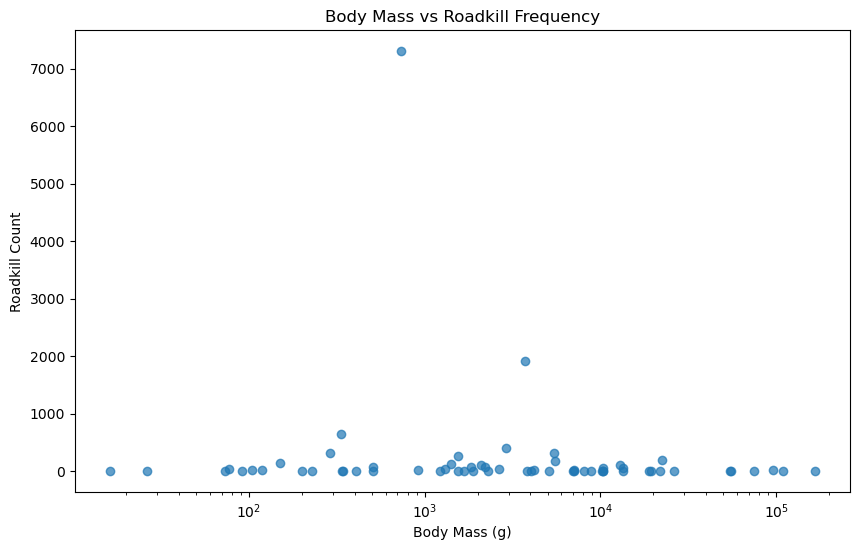

In [185]:
plot_df = kills_and_sizes.dropna(
    subset=["roadkill_count", "BodyMass-Value"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["BodyMass-Value"],
    plot_df["roadkill_count"],
    alpha=0.7
)

plt.xscale("log")

plt.xlabel("Body Mass (g)")
plt.ylabel("Roadkill Count")
plt.title("Body Mass vs Roadkill Frequency")

plt.show()

Korrelation

In [ ]:
corr = plot_df["BodyMass-Value"].corr(
    plot_df["roadkill_count"],
    method="spearman"#This is a non-parametric measure of rank correlation,because the data might not be normally distributed or when the relationship is not linear.
)

kills_and_sizes.sort_values(by="BodyMass-Value", ascending=False).head(10)

heaviest_animals = kills_and_sizes.sort_values(by="BodyMass-Value", ascending=False).head(3)
#Rothirsch 200kg, Reh 45-60kg,Wildschwein 75-100kg
print("\nHeaviest Animals in Roadkill Data:")
for index, row in heaviest_animals.iterrows():
    print(f"Species: {row['analysis_species']}, Body Mass: {row['BodyMass-Value']}g, Roadkill Count: {row['roadkill_count']}")

print(f"\nCorrelation between Body Mass and Roadkill Count: {corr}")  # -0.19 very weak negative linear relationship between body mass and roadkill observations

most_killed_species = kills_and_sizes.sort_values(by="roadkill_count", ascending=False).head(4)
print("\nMost Killed Species in Roadkill Data:")
for index, row in most_killed_species.iterrows():
    print(f"Species: {row['analysis_species']}, Body Mass: {row['BodyMass-Value']}g, Roadkill Count: {row['roadkill_count']}")



Heaviest Animals in Roadkill Data:
Species: Cervus elaphus, Body Mass: 165015.85g, Roadkill Count: 2
Species: Cervus, Body Mass: 109007.925g, Roadkill Count: 6
Species: Sus scrofa, Body Mass: 96118.09g, Roadkill Count: 12

Correlation between Body Mass and Roadkill Count: -0.19631558876571192

Most Killed Species in Roadkill Data:
Species: Erinaceus, Body Mass: 731.775g, Roadkill Count: 7305
Species: Lepus europaeus, Body Mass: 3740.0g, Roadkill Count: 1908
Species: Sciurus vulgaris, Body Mass: 333.0g, Roadkill Count: 649
Species: Felis catus, Body Mass: 2884.8g, Roadkill Count: 402


Wanted to see if a Gaus Distribution could be suspected

In [187]:
plot_df = kills_and_sizes.dropna(
    subset=["BodyMass-Value", "roadkill_count"]
).copy()

rho, p = spearmanr(
    plot_df["BodyMass-Value"],
    plot_df["roadkill_count"]
)

print(f"Spearman correlation: {rho:.3f}")
print(f"p-value: {p:.4g}")#p_value is the probability of observing the data if the null hypothesis is true.

Spearman correlation: -0.196
p-value: 0.1262


The relationship was not statistically significant, suggesting that body size alone does not explain variation in roadkill occurrence among species in the dataset. The data does not provide strong enough evidence that body mass and roadkill frequency are related. Therefore the null hypothesis could not be rejected.

In [188]:
x_data = plot_df["BodyMass-Value"].values#get data values
y_data = plot_df["roadkill_count"].values

#bodymass logarithmieren
log_x = np.log(x_data)

#maps a bell curve to log-space
#Formel: A * exp(-((ln_x - mu) ** 2) / (2 * sigma ** 2)))
# log-normal probability distribution 
def gaussian_fit(ln_x, A, mu, sigma):
    return A * np.exp(
        -((ln_x - mu) ** 2) /
        (2 * sigma ** 2)
    )

initial_guess = [
    y_data.max(),#Guess Peak = Highest Kill
    np.mean(log_x),#Center of the distribution, guess is the mean of log_x
    np.std(log_x)# Variance, guess is the standard deviation of log_x
]

#The curve_fit function from scipy.optimize is used to fit the gaussian_fit function to the data. 
# It returns the optimal parameters (A, mu, sigma) that best fit the data.
params, _ = curve_fit(
    gaussian_fit,
    log_x,
    y_data,
    p0=initial_guess,
    maxfev=10000
)

A_fit, mu_fit, sigma_fit = params

#Since the fit is log, the values need to be scaled right.
x_smooth = np.logspace(
    np.log10(x_data.min()),
    np.log10(x_data.max()),
    500
)

y_smooth = gaussian_fit(
    np.log(x_smooth),
    A_fit,
    mu_fit,
    sigma_fit
)

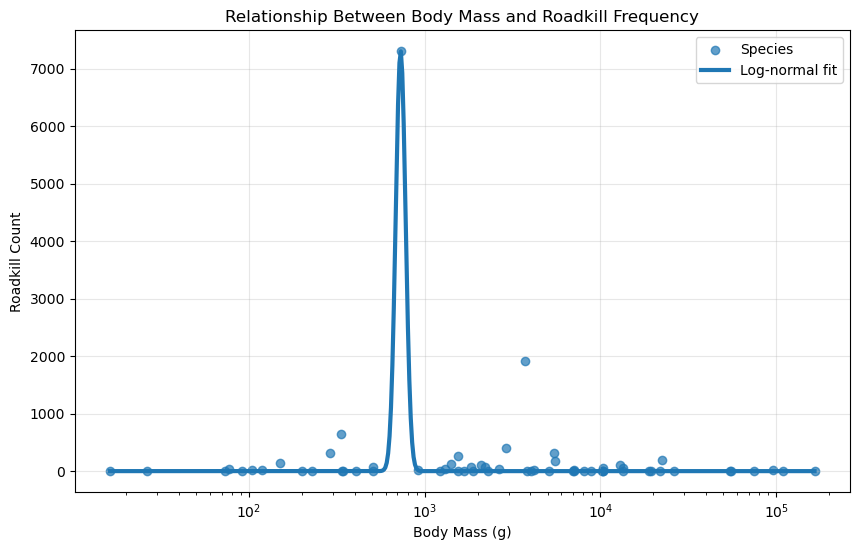

In [189]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x_data,
    y_data,
    alpha=0.7,
    label="Species"
)

plt.plot(
    x_smooth,
    y_smooth,
    linewidth=3,
    label="Log-normal fit"
)

plt.xscale("log")

plt.xlabel("Body Mass (g)")
plt.ylabel("Roadkill Count")
plt.title("Relationship Between Body Mass and Roadkill Frequency")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [190]:
peak_mass = np.exp(mu_fit)

print(
    f"Estimated peak roadkill occurrence at "
    f"{peak_mass/1000:.1f} kg"#Poor headghogs
)

Estimated peak roadkill occurrence at 0.7 kg


Wo/Wann werden die meisten Tiere überfahren und werden es mehr über die Jahre?

In [191]:
# Create time features
# %d = Day (06), %m = Month (02), %y = 2-digit Year (14)
df_animals["eventDate"] = pd.to_datetime(
    df_animals["eventDate"], 
    format="%d.%m.%y", 
    errors="coerce"
)

# New dataframe for time analysis
df_time = df_animals.copy()
df_time["Year"] = df_time["eventDate"].dt.year
df_time["Month"] = df_time["eventDate"].dt.month

# Verify Dates
print(df_time[["eventDate", "Year", "Month"]].dropna().head())

   eventDate    Year  Month
0 2014-02-06  2014.0    2.0
1 2014-02-27  2014.0    2.0
2 2014-02-27  2014.0    2.0
3 2014-02-28  2014.0    2.0
4 2014-03-01  2014.0    3.0


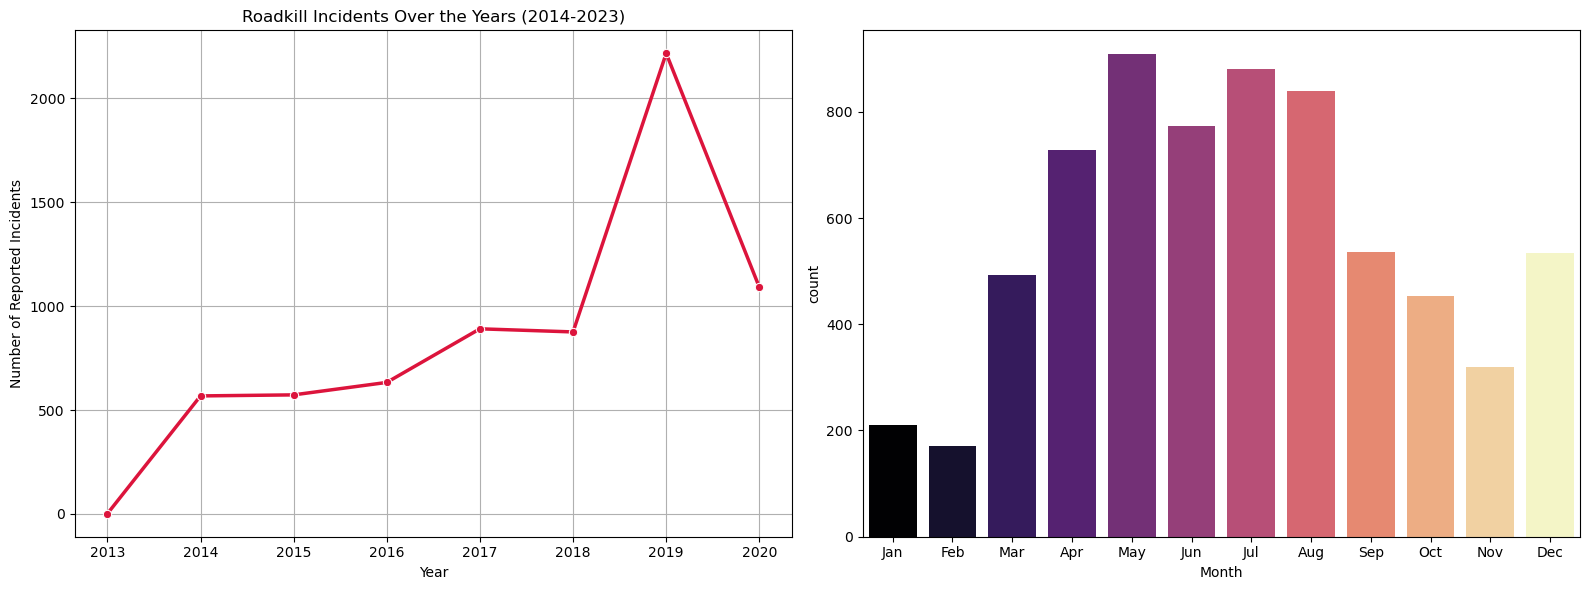

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#Two Plots, one for Yearly Trend and one for Monthly Distribution
#Yearly Trend
sns.lineplot(data=df_time['Year'].value_counts().sort_index(), ax=axes[0], marker="o", color="crimson", linewidth=2.5)
axes[0].set_title('Roadkill Incidents Over the Years (2014-2023)')
axes[0].set_ylabel('Number of Reported Incidents')
axes[0].set_xlabel('Year')
axes[0].grid(True)

#Define month labels
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

sns.countplot(
    data=df_time,
    x='Month',#one for scale, one for color
    hue='Month',
    palette='magma',
    legend=False,
    ax=axes[1]
)

# Monthly Distribution
axes[1].set_xticks(range(12))#set fixed tick amount (so no warnings)
axes[1].set_xticklabels(month_labels)#set month labels

plt.tight_layout()
plt.show()#2020 had a significant drop in roadkill incidents, likely due to COVID-19 lockdowns and reduced traffic.
#Increased incidents and traffics in spring increasing till summer and in autumn dropping. Some is because of less vehicles on the road
#Some is because of animal migration and mating seasons.

Nun zum Wo.

In [193]:
df_animals["lat_grid"] = df_animals["decimalLatitude"].round(2)
df_animals["lon_grid"] = df_animals["decimalLongitude"].round(2)

#Grid is a way to group nearby coordinates together, so instead of looking at exact lat/lon pairs, round them to 2 decimal places
#This helps to identify broader hotspots rather than just specific points.
hotspots_grid = (
    df_animals
    .groupby(["lat_grid", "lon_grid"])
    .size()
    .reset_index(name="roadkill_count")
    .sort_values("roadkill_count", ascending=False)
)

print(hotspots_grid.head(20))

      lat_grid  lon_grid  roadkill_count
4501     48.39     15.59             137
4080     48.28     16.07             110
4001     48.26     16.08              78
4035     48.27     16.07              68
4502     48.39     15.60              65
3954     48.25     16.09              53
2765     47.95     17.01              52
3955     48.25     16.10              48
3913     48.24     16.13              41
3911     48.24     16.11              36
2733     47.94     17.00              36
2679     47.92     16.99              32
4504     48.39     15.62              32
5576     53.48     10.21              31
4081     48.28     16.08              30
2802     47.96     17.02              30
4452     48.38     15.60              28
4078     48.28     16.05              25
3914     48.24     16.14              25
3912     48.24     16.12              23


In [194]:
#folim is for interactive maps
#It gets a starting point in the middle of the data and a zoom level
m = folium.Map(
    location=[
        df_animals["decimalLatitude"].mean(),
        df_animals["decimalLongitude"].mean()
    ],
    zoom_start=7
)

#this creates a list of [lat, lon] pairs for the heatmap, dropping any rows with missing coordinates
heat_data = df_animals[
    ["decimalLatitude", "decimalLongitude"]
].dropna().values.tolist()

#HeatMap takes the list of coordinates and adds it to the map, creating a heatmap layer that shows where roadkill incidents are most concentrated.
HeatMap(heat_data).add_to(m)
#Kernel Density Estimation (KDE) to generate an interactive raster overlay.
#it translates high-density point clusters into a continuous, smooth visual gradient
#places a localized 3D bell curve, peak by coordinates, till radius
m.save("temp_map.html")#save map

HotSpots in Austria

In [195]:
region_counts = (
    df_animals["name"]
    .value_counts()
    .reset_index(name="Roadkill_Count")
)
region_counts.columns = ["Region", "Roadkill_Count"]

#Most Deaths in den Bundesländern Österreichs
print(region_counts.head(10))

              Region  Roadkill_Count
0   Niederösterreich            2654
1  Niederoesterreich            2104
2         Burgenland            1245
3         Steiermark            1042
4               Wien             367
5     Oberösterreich             337
6              Tirol             271
7    Oberoesterreich             263
8           Salzburg             237
9            Kärnten             210
